# <span style="color:black; font-weight:bold;">13Million colorectal cancer multi-slices alignment Tutorial</span>
+ <span style="color:black; font-weight:bold;">Creator</span>: Bingjie Dai (17516970902@163.com)
+ <span style="color:black; font-weight:bold;">Date of Creation</span>: 10.8.2026
+ <span style="color:black; font-weight:bold;">Date of Last Modification</span>: 10.8.2026
+ <span style="color:black; font-weight:bold;">Download</span>:colorectal cancer multi-slices data used in the tutorial are available at [all slice](https://drive.google.com/file/d/1__lIeN1IpJ9uFC3Q2-wzkNe15ixOehSl/view?usp=sharing). Original data can been found in [Lin et al](https://doi.org/10.1016/j.cell.2022.12.028)
In this tutorial we apply MAPS to align colorectal_cancer multi-slices dataset. 

<span style="color:black; font-weight:bold;">The dataset have:</span>   
+ <span style="color:black; font-weight:bold;">slices</span>: 25 slices, Each slice is more than 400,000 cells,  totaling more than 10 million cells  

In [1]:
from MAPS.align import Multi_slices_rigid_alignment
from MAPS.utils import set_seed,create_new_color_dict
import scanpy as sc
import pandas as pd
import torch
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [3]:
set_seed(2026)

## <span style="color:black; font-weight:bold;">Loading colorectal_cancer multi-slices data</span>

In [4]:
import anndata as ad
import os, re

data_dir = "/home/dbj/shangjiao"
def slice_num(fname):
    return int(re.search(r'(\d+)', fname).group(1))

files = sorted((f for f in os.listdir(data_dir) if f.endswith(".h5ad")),key=slice_num)

adata_list = []
for f in files:
    a = ad.read_h5ad(os.path.join(data_dir, f))
    sid = f[:-5]
    print(f"Reading {sid:>12s} ...")
    adata_list.append(a)

Reading       slice2 ...
Reading       slice7 ...
Reading      slice14 ...
Reading      slice20 ...
Reading      slice25 ...
Reading      slice29 ...
Reading      slice34 ...
Reading      slice39 ...
Reading      slice44 ...
Reading      slice49 ...
Reading      slice50 ...
Reading      slice51 ...
Reading      slice52 ...
Reading      slice54 ...
Reading      slice59 ...
Reading      slice64 ...
Reading      slice69 ...
Reading      slice74 ...
Reading      slice78 ...
Reading      slice84 ...
Reading      slice86 ...
Reading      slice91 ...
Reading      slice97 ...
Reading     slice102 ...
Reading     slice106 ...


## <span style="color:black; font-weight:bold;">Before alignment</span>

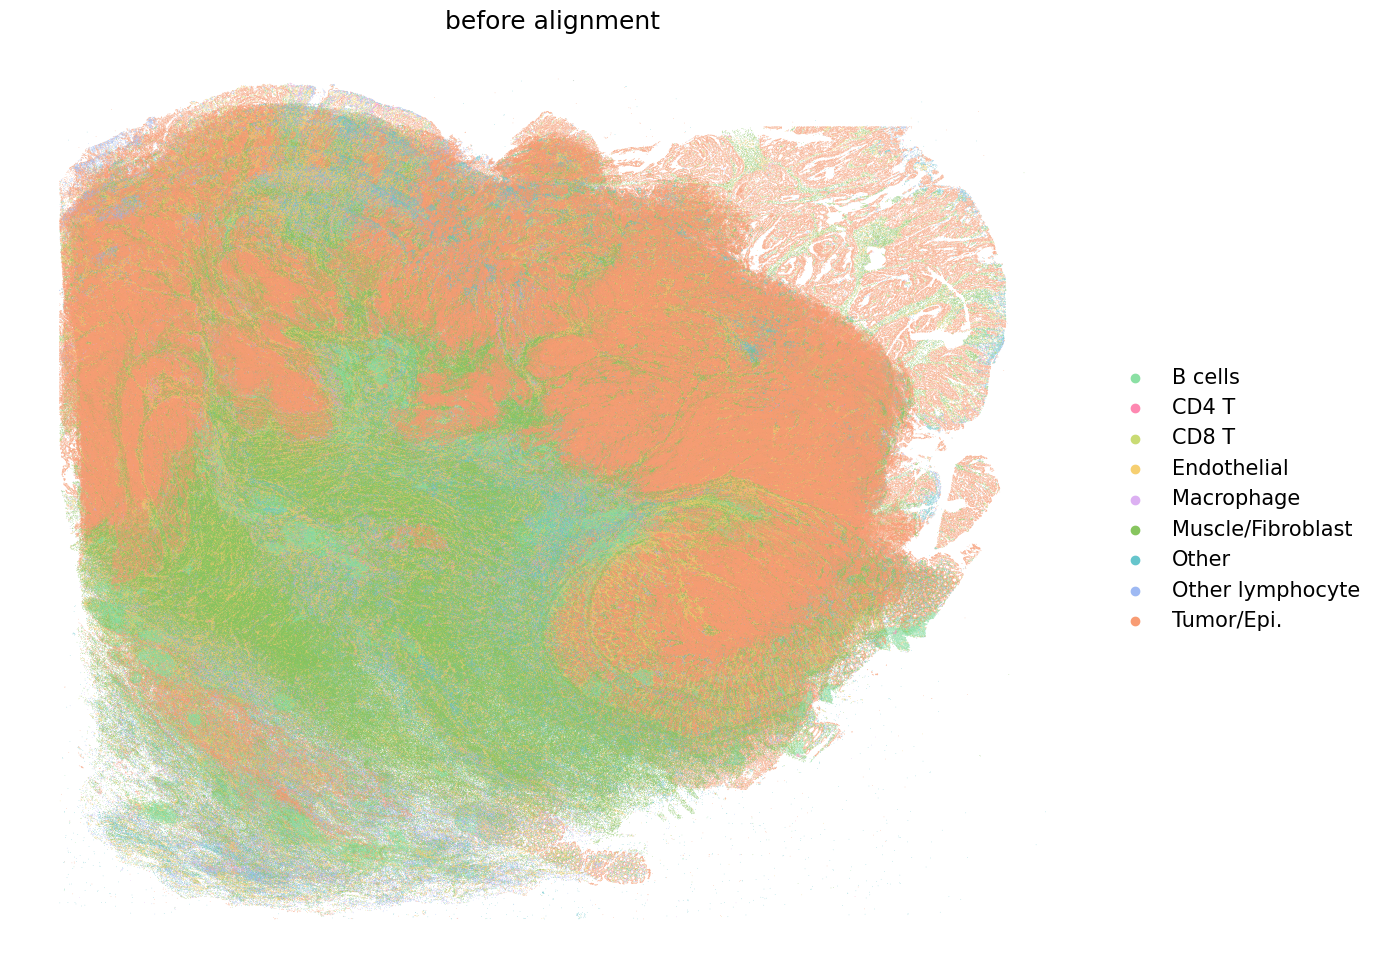

In [7]:
import matplotlib.pyplot as plt
import copy
plt.rcParams['figure.figsize'] = (14,12)
plt.rcParams['font.size'] = 15

adata=sc.concat(adata_list,join='inner')
color_dict=create_new_color_dict(adata,cat_key='cell_type_main')
sc.pl.embedding(adata=adata, basis='spatial',color='cell_type_main',title='before alignment',size=0.7,frameon=False,palette=color_dict)

## <span style="color:black; font-weight:bold;">Sequential align using MAPS for multi-slices</span> 
### <span style="color:black; font-weight:bold;">Training parameters</span> 
+ epochs: Training ephchs  
+ device: Training device  
+ sample_size: The number of samples used for alignment  
+ enable_scale: Whether to learn the scaling factor?  
+ mode: 'sequential' The slices are aligned in the order adata_list

### <span style="color:black; font-weight:bold;">Output</span>   
+ sequential_list: A list of slices aligned in order

In [8]:
sequential_adata_list = Multi_slices_rigid_alignment(adata_list, mode='sequential',epochs=1000, sample_size=20000, enable_scale=False, device=device)


--- Slice 1 is the first slice ---

--- Aligning Slice 2 to Slice 1 (sequential alignment) ---
Scanning angles to find best starting angle...


Global Align: 100%|████████████████████████████████| 1000/1000 [00:18<00:00, 52.65it/s, Loss=35.24, Scale=1.000, Rot=-79.40°, Trans=(2856.1, -1141.1)]


Peak GPU memory usage: 4.885 GB
Scale factor: 1.000, Rotation angle: -78.84°, Translation (x, y): (2856.10, -1138.42)

--- Aligning Slice 3 to Slice 2 (sequential alignment) ---
Scanning angles to find best starting angle...


Global Align: 100%|█████████████████████████████████| 1000/1000 [00:18<00:00, 54.36it/s, Loss=32.18, Scale=1.000, Rot=-91.92°, Trans=(2619.7, -621.5)]


Peak GPU memory usage: 4.883 GB
Scale factor: 1.000, Rotation angle: -92.18°, Translation (x, y): (2620.99, -619.43)

--- Aligning Slice 4 to Slice 3 (sequential alignment) ---
Scanning angles to find best starting angle...


...

Peak GPU memory usage: 4.888 GB
Scale factor: 1.000, Rotation angle: -83.16°, Translation (x, y): (2929.87, 336.50)

--- Aligning Slice 24 to Slice 23 (sequential alignment) ---
Scanning angles to find best starting angle...


Global Align: 100%|██████████████████████████████████| 1000/1000 [00:18<00:00, 53.99it/s, Loss=32.62, Scale=1.000, Rot=-80.91°, Trans=(2945.1, 668.1)]


Peak GPU memory usage: 4.889 GB
Scale factor: 1.000, Rotation angle: -80.60°, Translation (x, y): (2944.51, 668.22)

--- Aligning Slice 25 to Slice 24 (sequential alignment) ---
Scanning angles to find best starting angle...


Global Align: 100%|██████████████████████████████████| 1000/1000 [00:18<00:00, 54.02it/s, Loss=32.05, Scale=1.000, Rot=-89.08°, Trans=(2796.8, 976.8)]


Peak GPU memory usage: 4.889 GB
Scale factor: 1.000, Rotation angle: -89.18°, Translation (x, y): (2795.40, 976.15)

--- All slices have been aligned! ---


## <span style="color:black; font-weight:bold;">Spatial mapping of the sequential alignment result</span>

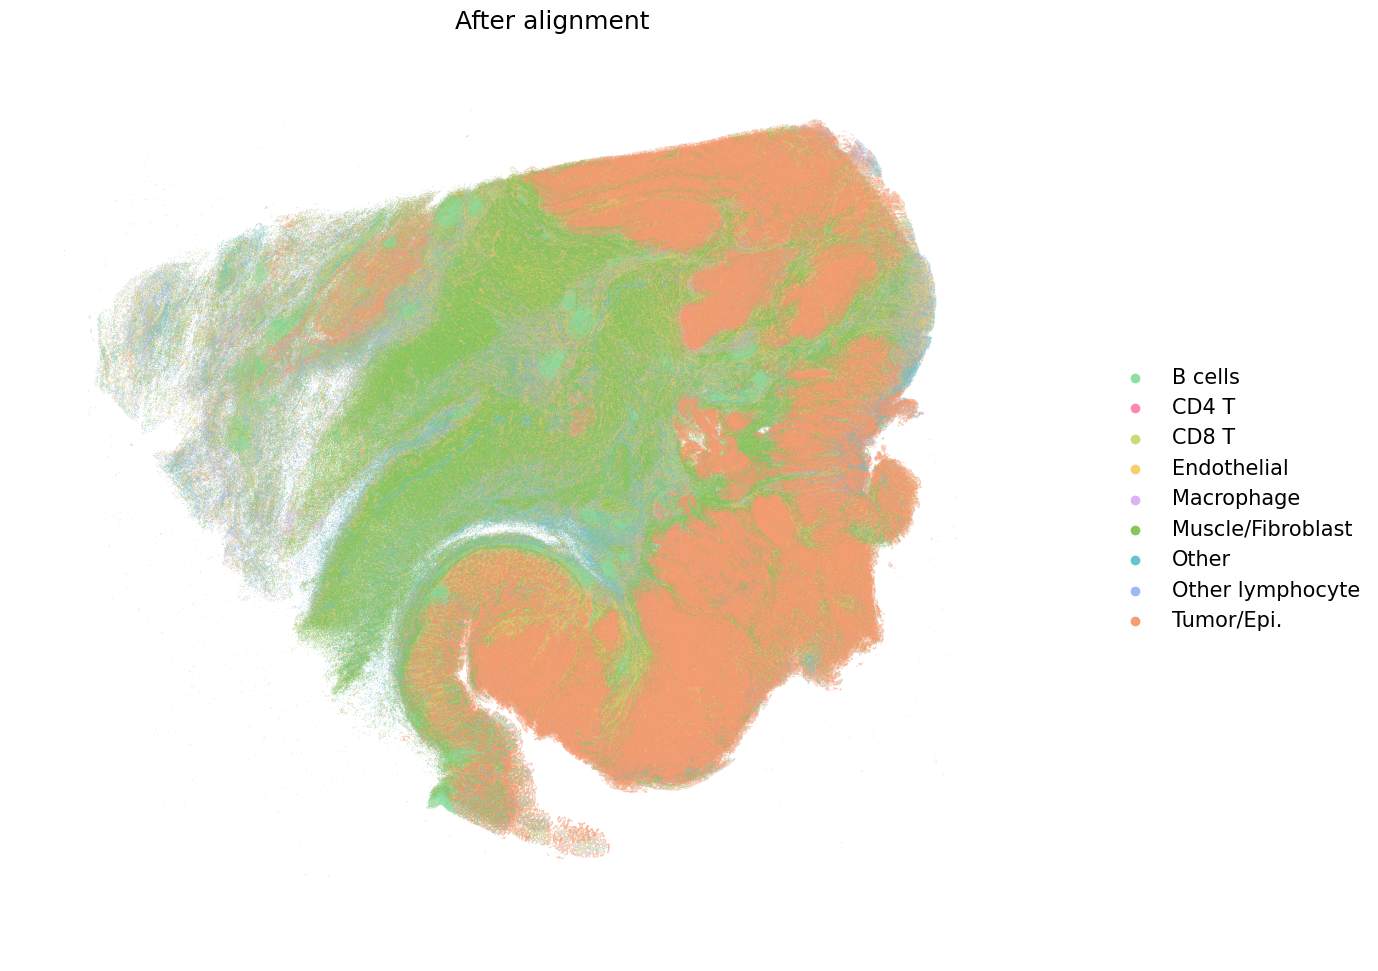

In [9]:
import matplotlib.pyplot as plt
import copy
plt.rcParams['figure.figsize'] = (14,12)
plt.rcParams['font.size'] = 15

adata=sc.concat(sequential_adata_list,join='inner')
color_dict=create_new_color_dict(adata,cat_key='cell_type_main')
sc.pl.embedding(adata=adata, basis='spatial',color='cell_type_main',title='After alignment',size=0.7,alpha=0.7,frameon=False,palette=color_dict)